In [13]:
from pathlib import Path
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

#Load existing dataset from CSV if it exists, otherwise create it from intial data 
#Return both the full dataframe and numpy arrays (x inputs, y outputs)
csv_path = Path("function_8_data.csv")

def load_or_create_dataset():
    if csv_path.exists():
        df = pd.read_csv(csv_path)
    else:
        X_init = np.load('../data/initial_data/function_8/initial_inputs.npy')
        y_init = np.load('../data/initial_data/function_8/initial_outputs.npy')

        df = pd.DataFrame(X_init, columns=['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8'])
        df['y'] = y_init
        df.to_csv(csv_path, index=False)

    X = df[['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8']].to_numpy()
    y = df['y'].to_numpy()

    return df, X, y

df, X, y = load_or_create_dataset()


#Checking shape of data 
print('Inputs Shape:', X.shape)
print('Outputs Shape:', y.shape)


Inputs Shape: (53, 8)
Outputs Shape: (53,)


In [15]:
#Append newly observed datapoints to existing CSV to keep a single up to date dataset

#Create a function to do this
def append_bo_result(x_new, y_new):
    df = pd.read_csv(csv_path)
    new_row = pd.DataFrame([[x_new[0], x_new[1], x_new[2], x_new[3], x_new[4], x_new[5], x_new[6], x_new[7], y_new]], columns=df.columns)
    df = pd.concat([df, new_row], ignore_index=True)
    df.to_csv(csv_path, index=False)
    return df
    
#Adding new values to my CSV df
#x_new = [0.087620, 0.283766, 0.198043, 0.010183, 0.806732, 0.257449, 0.263252, 0.960983]
#y_new = 9.8684756342581

#df = append_bo_result(x_new, y_new)

# Refresh X and y from the updated live dataframe
X = df[['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8']].to_numpy()
y = df['y'].to_numpy()

df.tail()

,x1,x2,x3,x4,x5,x6,x7,x8,y
48,0.180649,0.047496,0.025889,0.115898,0.999240,0.788337,0.066417,0.703984,9.803048
49,0.023958,0.298434,0.190419,0.013289,0.823843,0.741269,0.036774,0.325994,9.817473
50,0.039417,0.247008,0.089696,0.297166,0.796669,0.395690,0.002053,0.626307,9.867396
51,0.188357,0.246513,0.279683,0.091709,0.920051,0.449164,0.107744,0.925598,9.867044
52,0.087620,0.283766,0.198043,0.010183,0.806732,0.257449,0.263252,0.960983,9.868476


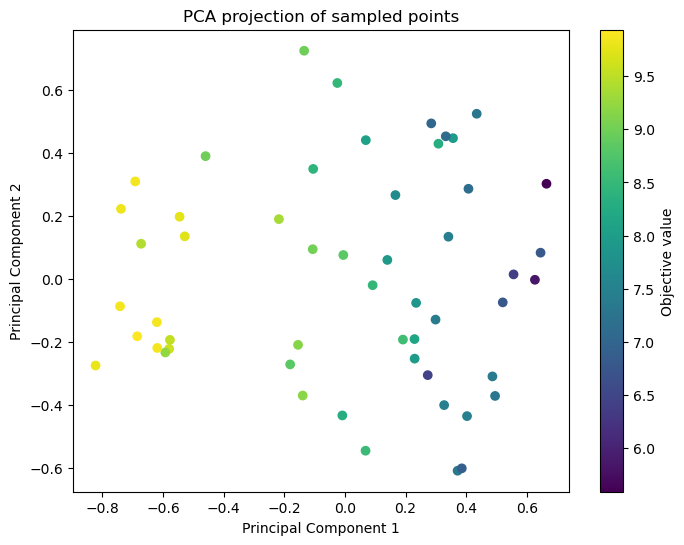

In [18]:
#Create a PCA plot to visulize patterns in the data 

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)
plt.colorbar(scatter, label="Objective value")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA projection of sampled points")
plt.show()

In [19]:
#Define GP hyperparameters and make a grid / generate random candidate points for acqusition optimisation 

import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C

#hyperparamters for GP surrogate model and acqusition function 
#matern_lengthscale = 0.3 lengthscale setting week 1 - 11
matern_lengthscale = np.full(8, 0.3) #lengthscale week 12-13, allowing each dimension to be optimised individually
nu = 1.5 #controls bumpiness
noise_assumption = 0.05 #gp will reestiamte 
xi = 0.01

#Setting number of random candidate points
n_candidates = 10000 

# sample uniformly in [0, 1]^8
X_candidates = np.random.rand(n_candidates, 8)



In [20]:
#Fit the GP to current data

kernel = (C(1.0, (1e-2, 1e2)) * Matern(length_scale = np.full(8, 0.3), length_scale_bounds=(1e-2, 8), nu=1.5) 
    + WhiteKernel(noise_level=0.05, noise_level_bounds=(1e-5, 1)))
gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=15, random_state=0)
gp.fit(X, y)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 4 of parameter k1__k2__length_scale is close to the specified upper bound 8.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 7 of parameter k1__k2__length_scale is close to the specified upper bound 8.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


GaussianProcessRegressor(kernel=1**2 * Matern(length_scale=[0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3], nu=1.5) + WhiteKernel(noise_level=0.05),
                         n_restarts_optimizer=15, normalize_y=True,
                         random_state=0)

In [23]:
#Setting up and running acqusition function 
 
from scipy.stats import norm
import numpy as np

#Expected Improvement (Queries 10-13)

#Writing the function 
def expected_improvement(mu, sigma, y_best, xi=0.01):
    sigma = np.maximum(sigma, 1e-12)
    imp = mu - y_best - xi
    Z = imp / sigma
    return imp * norm.cdf(Z) + sigma * norm.pdf(Z)

# Predict GP on candidate set
mu, std = gp.predict(X_candidates, return_std=True)

# Best observed so far (maximization)
y_best = float(np.max(y))

# Compute EI and use it to select next point
ei = expected_improvement(mu, std, y_best, xi=0.01)
ix = int(np.argmax(ei))
x_next = X_candidates[ix]
print(f"x_next = ({x_next[0]:.6f}, {x_next[1]:.6f},{x_next[2]:.6f},{x_next[3]:.6f},{x_next[4]:.6f},{x_next[5]:.6f},{x_next[6]:.6f}, {x_next[7]:.6f} ) ")



# Probability of Improvement (Considered for queries 12 - 13)

#Writing the function
def probability_of_improvement(mu, sigma, y_best, xi=0.01):
    sigma = np.maximum(sigma, 1e-12)
    Z = (mu - y_best - xi) / sigma
    return norm.cdf(Z)

# Predict GP on candidate set
mu, std = gp.predict(X_candidates, return_std=True)

# Best observed so far (maximization)
y_best = float(np.max(y))

# Compute PI and use it to select next point
pi = probability_of_improvement(mu, std, y_best, xi=0.01)
ix = int(np.argmax(pi))
x_next = X_candidates[ix]

print(f"x_next = ({x_next[0]:.6f}, {x_next[1]:.6f}, {x_next[2]:.6f}, {x_next[3]:.6f}, "f"{x_next[4]:.6f}, {x_next[5]:.6f}, {x_next[6]:.6f}, {x_next[7]:.6f})")


# Compute UCB (Used in queries 1-10) 
#ucb = mu + beta * sigma
#ix = np.argmax(ucb)
#x_next = X_candidates[ix]
#print(f"x_next = ({x_next[0]:.6f}, {x_next[1]:.6f},{x_next[2]:.6f},{x_next[3]:.6f},{x_next[4]:.6f},{x_next[5]:.6f},{x_next[6]:.6f},{x_next[7]:.6f} ) ")

x_next = (0.075777, 0.184229,0.102144,0.128103,0.615934,0.634464,0.132818, 0.946509 ) 
x_next = (0.075777, 0.184229, 0.102144, 0.128103, 0.615934, 0.634464, 0.132818, 0.946509)


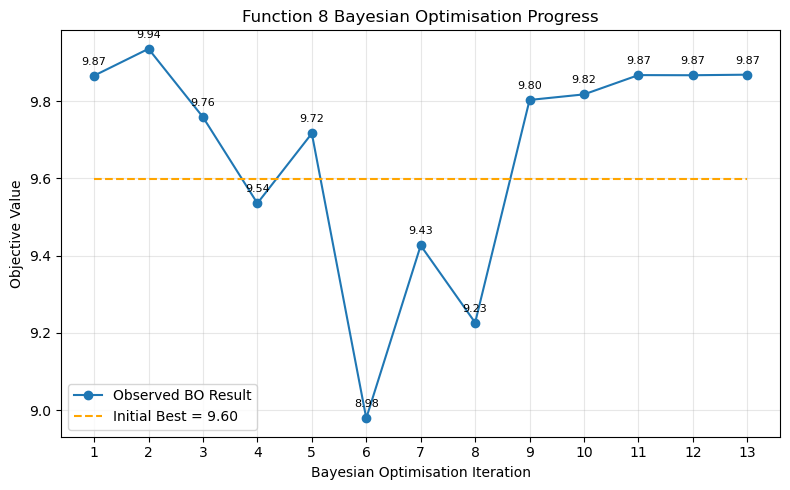

In [28]:
# Plot a graph to track function_8 Bayesian Optimisation progress 

#Intial y_best existing in origional dataset 
INITIAL_BEST_Y = 9.598482  

# Load my live CSV data file 
df_plot = pd.read_csv(csv_path)
df_plot["y"] = pd.to_numeric(df_plot["y"], errors="coerce")

# Select Bayesian Optimisation data from existing dataset and assign them indexes for plotting
bo = df_plot.tail(13).copy()
bo["iteration"] = range(1, len(bo) + 1)

x = bo["iteration"]
y = bo["y"]

# Flat baseline using your manual value
baseline = np.full(len(y), INITIAL_BEST_Y)

# Plot the graph 
plt.figure(figsize=(8, 5))

plt.plot(x, y, marker="o", label="Observed BO Result")
plt.plot(x, baseline, linestyle="--", color="orange", label=f"Initial Best = {INITIAL_BEST_Y:.2f}")

# Labels on points
for i, val in zip(x, y):
    plt.annotate(f"{val:.2f}", (i, val), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)

plt.xlabel("Bayesian Optimisation Iteration")
plt.ylabel("Objective Value")
plt.title("Function 8 Bayesian Optimisation Progress")
plt.xticks(x)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig("function_8_bo_progress.png", dpi=300, bbox_inches="tight")
plt.show()